# 🚗 Bengaluru Parking Violation Intelligence — Phase 2
### AI Hotspot Clustering & Congestion Impact Scoring

**Builds on Phase 1.** This notebook assumes you have already run the Phase 1
notebook and have these files available (either in `/kaggle/working/` from the
same session, or uploaded as a Kaggle dataset):

- `violations_geocoded.csv` — cleaned, enriched violation records
- `h3_hexagons.csv` — H3 hex-level aggregated risk scores

**This notebook (Phase 2) covers:**
1. Setup & load Phase 1 outputs
2. DBSCAN spatial clustering → natural hotspot zones (not just admin junctions)
3. Congestion Impact Index (CII) — a composite score combining frequency, severity, and persistence
7. Ranked enforcement zone list — the actionable output for patrol deployment
8. Interactive cluster map
9. Export all artifacts for Phase 3 (dashboard)

> **Honesty note:** A naive model regressing total risk score on violation count
> gives a misleadingly perfect R² (~0.99) because risk score is almost a direct
> function of count. We deliberately build the *harder, more useful* model instead:
> forecasting **future** violation volume from historical patterns — which is what
> actually helps a patrol commander deploy resources before violations happen.


In [6]:
# Install packages not pre-installed on Kaggle
!pip install -q h3 folium branca

import pandas as pd
import numpy as np
import re
import json
import time
import os
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
import h3
import folium
from folium.plugins import HeatMap, MarkerCluster, MiniMap

from sklearn.cluster import DBSCAN
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb


sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10

print("✓ Libraries loaded")
print(f"  h3 version     : {h3.__version__}")
print(f"  folium version : {folium.__version__}")
print(f"  pandas version : {pd.__version__}")



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


✓ Libraries loaded
  h3 version     : 4.5.0
  folium version : 0.20.0
  pandas version : 2.3.3


In [3]:
# ── EDIT THESE PATHS if needed ────────────────────────────────
VIOLATIONS_PATH = "violations_geocoded.csv"
HEXAGONS_PATH   = "h3_hexagons.csv"

import os, glob

def find_file(preferred_path, filename):
    if os.path.exists(preferred_path):
        return preferred_path
    candidates = glob.glob(f"/kaggle/input/**/{filename}", recursive=True)
    if candidates:
        print(f"⚠ Auto-detected {filename} at: {candidates[0]}")
        return candidates[0]
    raise FileNotFoundError(
        f"{filename} not found. Run Phase 1 first, or upload its outputs as a dataset."
    )

VIOLATIONS_PATH = find_file(VIOLATIONS_PATH, "violations_geocoded.csv")
HEXAGONS_PATH   = find_file(HEXAGONS_PATH, "h3_hexagons.csv")

df    = pd.read_csv(VIOLATIONS_PATH)
hexdf = pd.read_csv(HEXAGONS_PATH)
df["date"] = pd.to_datetime(df["date"])

print(f"✓ Violations loaded : {len(df):,} rows")
print(f"✓ H3 hexagons loaded: {len(hexdf):,} zones")
print(f"  Date range: {df['date'].min().date()} → {df['date'].max().date()}  "
      f"({(df['date'].max()-df['date'].min()).days + 1} days)")


✓ Violations loaded : 122,404 rows
✓ H3 hexagons loaded: 674 zones
  Date range: 2023-11-09 → 2024-03-29  (142 days)


In [4]:
np.random.seed(42)

HIGH_RISK_THRESHOLD = 8        # keep every high-impact violation
LOW_RISK_SAMPLE_SIZE = 50000   # representative sample of the rest

high_risk = df[df["risk_score_raw"] >= HIGH_RISK_THRESHOLD]
low_risk_pool = df[df["risk_score_raw"] < HIGH_RISK_THRESHOLD]
low_risk = low_risk_pool.sample(n=min(LOW_RISK_SAMPLE_SIZE, len(low_risk_pool)), random_state=42)

sample = pd.concat([high_risk, low_risk]).reset_index(drop=True)

print(f"High-risk violations (kept in full)  : {len(high_risk):,}")
print(f"Low-risk violations (sampled)        : {len(low_risk):,}")
print(f"Total clustering sample               : {len(sample):,}  (vs {len(df):,} full dataset)")


High-risk violations (kept in full)  : 18,363
Low-risk violations (sampled)        : 50,000
Total clustering sample               : 68,363  (vs 122,404 full dataset)


In [7]:
# ── Run DBSCAN with haversine distance (true geographic distance) ──
EPS_METERS    = 150   # cluster radius — roughly one urban block
MIN_SAMPLES   = 25    # minimum violations to form a hotspot (filters out noise)
EARTH_RADIUS_M = 6371000

coords = np.radians(sample[["latitude", "longitude"]].values)
eps_rad = EPS_METERS / EARTH_RADIUS_M

t0 = time.time()
db = DBSCAN(eps=eps_rad, min_samples=MIN_SAMPLES, metric="haversine",
            algorithm="ball_tree", n_jobs=-1).fit(coords)
print(f"DBSCAN runtime: {time.time()-t0:.2f}s")

sample["cluster"] = db.labels_
n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise    = (db.labels_ == -1).sum()

print(f"✓ Hotspot clusters found : {n_clusters}")
print(f"  Noise points (isolated): {n_noise:,} / {len(sample):,} ({n_noise/len(sample)*100:.1f}%)")


DBSCAN runtime: 1.01s
✓ Hotspot clusters found : 182
  Noise points (isolated): 5,926 / 68,363 (8.7%)


In [8]:
# ── Summarise each cluster into a ranked hotspot table ──────
clustered = sample[sample["cluster"] != -1]

hotspots = clustered.groupby("cluster").agg(
    n_violations      = ("id", "count"),
    total_risk        = ("risk_score_raw", "sum"),
    mean_risk         = ("risk_score_raw", "mean"),
    lat               = ("latitude", "mean"),
    lon               = ("longitude", "mean"),
    dominant_type     = ("primary_violation", lambda x: x.value_counts().index[0]),
    dominant_vehicle  = ("updated_vehicle_type", lambda x: x.value_counts().index[0]),
    dominant_station  = ("police_station", lambda x: x.value_counts().index[0]),
    junction_name     = ("junction_resolved", lambda x: x.value_counts().index[0]),
).reset_index().sort_values("total_risk", ascending=False).reset_index(drop=True)

hotspots["rank"] = hotspots.index + 1
hotspots["radius_m"] = EPS_METERS  # approx cluster footprint for mapping

print(f"✓ {len(hotspots)} ranked hotspot zones identified\n")
hotspots[["rank","junction_name","n_violations","total_risk","dominant_type","dominant_station"]].head(15)


✓ 182 ranked hotspot zones identified



,rank,junction_name,n_violations,total_risk,dominant_type,dominant_station
0,1,BTP044 - Sagar Theatre Junction,14602,88981,WRONG PARKING,Upparpet
1,2,Area-12.933N-77.691E,4472,35399,PARKING IN A MAIN ROAD,HAL Old Airport
2,3,BTP051 - Safina Plaza Junction,5818,29795,WRONG PARKING,Shivajinagar
3,4,BTP027 - Modi Bridge Junction,4069,20984,WRONG PARKING,Malleshwaram
4,5,Area-13.188N-77.678E,1410,12686,NO PARKING,Chikkajala
5,6,"BTP011 - RR Kalyana Mantapa, Dr. Rajkumar Road",2125,11610,WRONG PARKING,Malleshwaram
6,7,"BTP011 - RR Kalyana Mantapa, Dr. Rajkumar Road",1118,7573,WRONG PARKING,Rajajinagar
7,8,BTP020 - Hosahalli Metro Station,1978,7210,NO PARKING,Vijayanagara
8,9,Area-12.963N-77.717E,941,6834,WRONG PARKING,HAL Old Airport
9,10,BTP144 - Commando Hospital Junction,945,6595,NO PARKING,Halasur


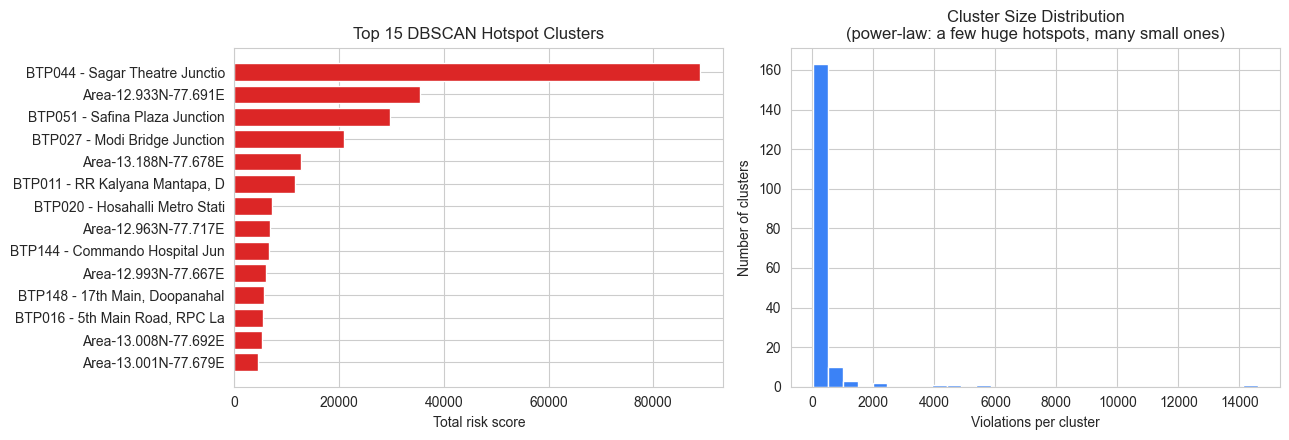

In [9]:
# ── Visualise cluster size distribution ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))

top15 = hotspots.head(15).iloc[::-1]
axes[0].barh(top15["junction_name"].str[:30], top15["total_risk"], color="#dc2626")
axes[0].set_xlabel("Total risk score")
axes[0].set_title("Top 15 DBSCAN Hotspot Clusters")

axes[1].hist(hotspots["n_violations"], bins=30, color="#3b82f6", edgecolor="white")
axes[1].set_xlabel("Violations per cluster")
axes[1].set_ylabel("Number of clusters")
axes[1].set_title("Cluster Size Distribution\n(power-law: a few huge hotspots, many small ones)")

plt.tight_layout(); plt.show()


## 4. Congestion Impact Index (CII)

A violation count alone doesn't tell a commander *how much it actually disrupts
traffic*. We combine three signals into a single 0–100 score per H3 zone:

- **Frequency** — violations per day (how often the obstruction recurs)
- **Severity** — mean risk score (main-road / heavy-vehicle violations weigh more)
- **Persistence** — neighbourhood-smoothed risk percentile (is this part of a
  wider problem area, or an isolated blip?)

This reuses the `mean_risk` and `smoothed_risk` columns already computed in
Phase 1's H3 aggregation — no new external traffic API needed for the prototype.
A real deployment would blend in live traffic-speed data here (see the notes at
the end of this section).


In [10]:
N_DAYS = (df["date"].max() - df["date"].min()).days + 1
print(f"Dataset spans {N_DAYS} days — used to normalise frequency.")

hexdf["violations_per_day"] = hexdf["count"] / N_DAYS

# Composite Congestion Impact Index — weighted blend, then rescaled 0-100
hexdf["cii_raw"] = (
    hexdf["violations_per_day"] * 0.40 +
    hexdf["mean_risk"]          * 0.40 +
    hexdf["smoothed_risk"].rank(pct=True) * 100 * 0.20
)
hexdf["cii"] = (hexdf["cii_raw"] / hexdf["cii_raw"].max() * 100).round(1)

def cii_tier(score):
    if score >= 70: return "SEVERE"
    if score >= 45: return "HIGH"
    if score >= 20: return "MODERATE"
    return "LOW"

hexdf["cii_tier"] = hexdf["cii"].apply(cii_tier)

print("\n✓ Congestion Impact Index computed")
print(hexdf["cii_tier"].value_counts())


Dataset spans 142 days — used to normalise frequency.

✓ Congestion Impact Index computed
cii_tier
MODERATE    376
LOW         236
HIGH         58
SEVERE        4
Name: count, dtype: int64


In [11]:
# ── Top zones by Congestion Impact Index ─────────────────────
top_cii = hexdf.sort_values("cii", ascending=False).head(15)[
    ["dominant_station","dominant_type","count","violations_per_day","mean_risk","cii","cii_tier"]
]
print("Top 15 zones by Congestion Impact Index:")
top_cii


Top 15 zones by Congestion Impact Index:


,dominant_station,dominant_type,count,violations_per_day,mean_risk,cii,cii_tier
208,Upparpet,WRONG PARKING,9460,66.619718,5.218288,100.0,SEVERE
626,Shivajinagar,WRONG PARKING,6076,42.788732,4.777814,79.7,SEVERE
212,Upparpet,WRONG PARKING,5216,36.732394,4.761887,75.2,SEVERE
200,Upparpet,NO PARKING,4504,31.718310,6.015542,72.0,SEVERE
210,City Market,WRONG PARKING,3315,23.345070,5.649170,64.5,HIGH
274,HAL Old Airport,NO PARKING,3236,22.788732,5.079419,62.5,HIGH
197,Malleshwaram,WRONG PARKING,3008,21.183099,4.456117,60.9,HIGH
445,Halasuru Gate,WRONG PARKING,2727,19.204225,5.240191,60.8,HIGH
622,Shivajinagar,WRONG PARKING,2282,16.070423,5.783961,58.4,HIGH
192,Malleshwaram,WRONG PARKING,1956,13.774648,4.983129,55.1,HIGH


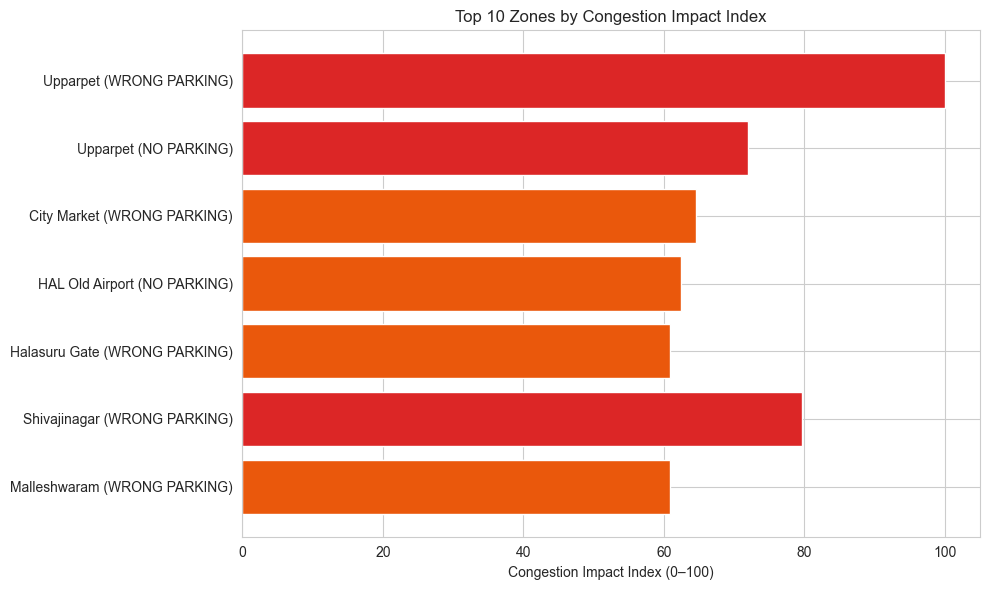

In [12]:
fig, ax = plt.subplots(figsize=(10,6))
top10cii = hexdf.sort_values("cii", ascending=False).head(10).iloc[::-1]
colors = top10cii["cii_tier"].map({"SEVERE":"#dc2626","HIGH":"#ea580c","MODERATE":"#d97706","LOW":"#22c55e"})
ax.barh(top10cii["dominant_station"] + " (" + top10cii["dominant_type"].str[:15] + ")", top10cii["cii"], color=colors)
ax.set_xlabel("Congestion Impact Index (0–100)")
ax.set_title("Top 10 Zones by Congestion Impact Index")
plt.tight_layout(); plt.show()


## 5. Ranked Enforcement Priority List

This is the single most actionable output of Phase 2: every zone ranked by a
**blended priority score** combining historical risk, the Congestion Impact
Index, and (where available) the model's next-day volume forecast. This is what
would feed directly into a patrol-deployment dashboard.


In [13]:
# ── Merge CII into the hotspot table and build final priority ranking ──
hex_lookup = hexdf.set_index("h3_cell")[["cii","cii_tier","violations_per_day"]]

# Map each DBSCAN cluster centroid to its nearest H3 cell for CII lookup
def nearest_h3(lat, lon):
    return h3.latlng_to_cell(lat, lon, 8)

hotspots["h3_cell"] = hotspots.apply(lambda r: nearest_h3(r["lat"], r["lon"]), axis=1)
hotspots = hotspots.merge(hex_lookup, on="h3_cell", how="left")

# Final priority score: 60% historical risk + 40% congestion impact index
hotspots["risk_pct"] = (hotspots["total_risk"].rank(pct=True) * 100)
hotspots["priority_score"] = (hotspots["risk_pct"] * 0.6 + hotspots["cii"].fillna(0) * 0.4).round(1)
hotspots = hotspots.sort_values("priority_score", ascending=False).reset_index(drop=True)
hotspots["priority_rank"] = hotspots.index + 1

priority_table = hotspots[[
    "priority_rank","junction_name","n_violations","total_risk",
    "cii","cii_tier","dominant_type","dominant_vehicle","dominant_station","lat","lon"
]]

print("✓ Final ranked enforcement priority list (top 20):\n")
priority_table.head(20)


✓ Final ranked enforcement priority list (top 20):



,priority_rank,junction_name,n_violations,total_risk,cii,cii_tier,dominant_type,dominant_vehicle,dominant_station,lat,lon
0,1,BTP051 - Safina Plaza Junction,5818,29795,79.7,SEVERE,WRONG PARKING,SCOOTER,Shivajinagar,12.981909,77.606957
1,2,BTP044 - Sagar Theatre Junction,14602,88981,75.2,SEVERE,WRONG PARKING,SCOOTER,Upparpet,12.972532,77.577413
2,3,Area-12.933N-77.691E,4472,35399,62.5,HIGH,PARKING IN A MAIN ROAD,CAR,HAL Old Airport,12.935329,77.691172
3,4,BTP027 - Modi Bridge Junction,4069,20984,60.9,HIGH,WRONG PARKING,CAR,Malleshwaram,13.004759,77.551392
4,5,Area-13.188N-77.678E,1410,12686,52.9,HIGH,NO PARKING,MAXI-CAB,Chikkajala,13.185193,77.680386
5,6,"BTP011 - RR Kalyana Mantapa, Dr. Rajkumar Road",2125,11610,51.0,HIGH,WRONG PARKING,CAR,Malleshwaram,13.000267,77.571233
6,7,"BTP011 - RR Kalyana Mantapa, Dr. Rajkumar Road",1118,7573,48.5,HIGH,WRONG PARKING,CAR,Rajajinagar,12.989058,77.552695
7,8,Area-12.963N-77.717E,941,6834,48.3,HIGH,WRONG PARKING,MAXI-CAB,HAL Old Airport,12.963350,77.717306
8,9,BTP020 - Hosahalli Metro Station,1978,7210,46.1,HIGH,NO PARKING,SCOOTER,Vijayanagara,12.974364,77.547172
9,10,"BTP016 - 5th Main Road, RPC Layout",1161,5421,48.9,HIGH,WRONG PARKING,SCOOTER,Vijayanagara,12.967078,77.537794


## 7. Interactive Cluster Map

In [14]:
BLR_CENTER = [12.9716, 77.5946]
m = folium.Map(location=BLR_CENTER, zoom_start=12, tiles="CartoDB Positron", prefer_canvas=True)
MiniMap(toggle_display=True).add_to(m)

cluster_layer = folium.FeatureGroup(name="DBSCAN hotspot clusters", show=True)
mc = MarkerCluster().add_to(cluster_layer)

for _, row in priority_table.head(30).iterrows():
    rank = int(row["priority_rank"])
    color = "red" if rank <= 5 else "orange" if rank <= 15 else "blue"
    popup_html = f'''<div style="font-family:sans-serif;font-size:13px;min-width:250px">
      <b>#{rank} — {row["junction_name"]}</b><br><br>
      Violations: <b>{int(row["n_violations"]):,}</b><br>
      Risk score: <b>{int(row["total_risk"]):,}</b><br>
      Congestion Impact Index: <b>{row["cii"]:.1f}</b> ({row["cii_tier"]})<br>
      Top violation: {row["dominant_type"]}<br>
      Top vehicle: {row["dominant_vehicle"]}<br>
      Station: {row["dominant_station"]}
      </div>'''
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=8 + min(rank, 20) * -0.3,
        color=color, fill=True, fill_color=color, fill_opacity=0.7,
        popup=folium.Popup(popup_html, max_width=300),
        tooltip=f"#{rank} {row['junction_name'][:30]} | Priority: {row['priority_score'] if 'priority_score' in row else ''}",
    ).add_to(mc)

cluster_layer.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)

map_path = Path(".") / "phase2_hotspot_clusters.html"
m.save(str(map_path))
print(f"✓ Cluster map saved to {map_path}")
m


✓ Cluster map saved to phase2_hotspot_clusters.html


In [17]:
OUTPUT_DIR = Path(".")

hotspots.to_csv(OUTPUT_DIR / "dbscan_hotspot_clusters.csv", index=False)
hexdf.to_csv(OUTPUT_DIR / "h3_hexagons_with_cii.csv", index=False)
priority_table.to_csv(OUTPUT_DIR / "enforcement_priority_ranking.csv", index=False)

print("✓ Phase 2 artifacts saved to /kaggle/working/:")
for f in sorted(OUTPUT_DIR.glob("*")):
    if f.is_file():
        print(f"   {f.name}")

print(f"\n{'='*55}")
print("PHASE 2 SUMMARY")
print(f"{'='*55}")
print(f'''
DBSCAN hotspot clusters found     : {len(hotspots)}
Top priority zone                 : {priority_table.iloc[0]["junction_name"]}
Zones with SEVERE/HIGH CII        : {(hexdf["cii_tier"].isin(["SEVERE","HIGH"])).sum()}
''')
print("Next → Phase 3: build the live commander-facing dashboard from these outputs.")


✓ Phase 2 artifacts saved to /kaggle/working/:
   bengaluru_parking_heatmap.html
   daily_timeseries_features.csv
   dbscan_hotspot_clusters.csv
   eda_daily.csv
   eda_hourly.csv
   eda_monthly.csv
   eda_station_load.csv
   eda_top_junctions.csv
   eda_vehicle_risk.csv
   enforcement_priority_ranking.csv
   h3_hexagons.csv
   h3_hexagons_with_cii.csv
   jan to may police violation_anonymized791b166.csv
   notebookc86b1823d8.ipynb
   phase2_hotspot_clusters.html
   Untitled.ipynb
   Untitled1.ipynb
   violations_geocoded.csv
   xgb_violation_forecast_model.json

PHASE 2 SUMMARY

DBSCAN hotspot clusters found     : 182
Top priority zone                 : BTP051 - Safina Plaza Junction
Zones with SEVERE/HIGH CII        : 62

Next → Phase 3: build the live commander-facing dashboard from these outputs.
